In [2]:
import pandas as pd

url = "https://huggingface.co/datasets/Rodrigopiva/Social_Network_Ads.csv/resolve/main/Social_Network_Ads.csv"

df = pd.read_csv(url)

df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
df.shape

(400, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [6]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [7]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [8]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [11]:
df["Purchased"].value_counts(normalize=True)

Purchased
0    0.6425
1    0.3575
Name: proportion, dtype: float64

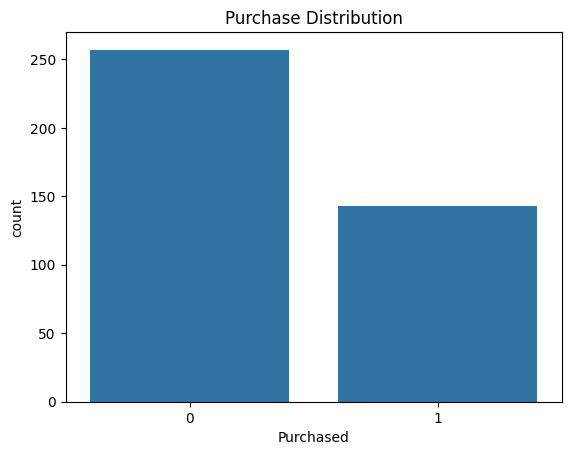

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Purchased", data=df)

plt.title("Purchase Distribution")
plt.show()

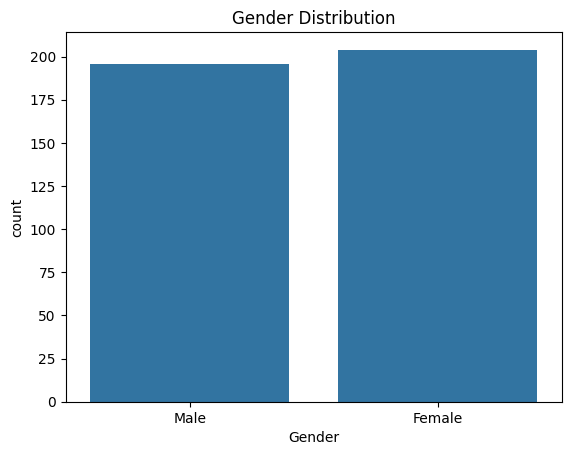

In [14]:
sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")
plt.show()

In [16]:
pd.crosstab(df["Gender"], df["Purchased"])

Purchased,0,1
Gender,,
Female,127,77
Male,130,66


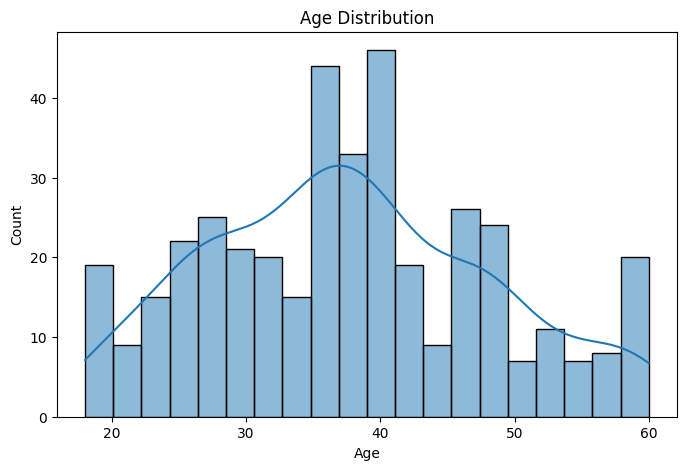

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

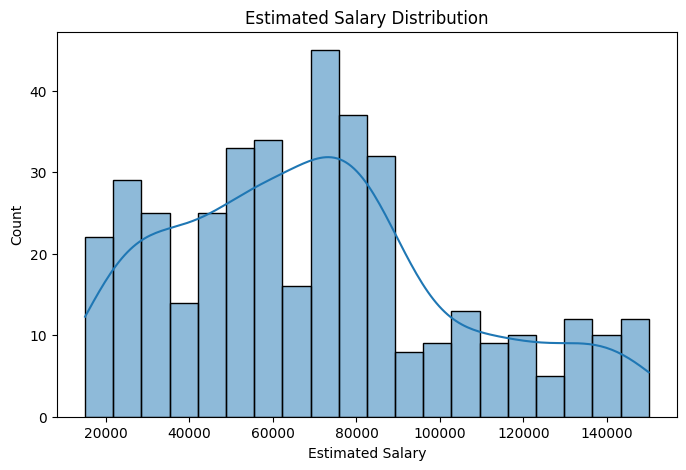

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["EstimatedSalary"],
    bins=20,
    kde=True
)

plt.title("Estimated Salary Distribution")
plt.xlabel("Estimated Salary")
plt.show()

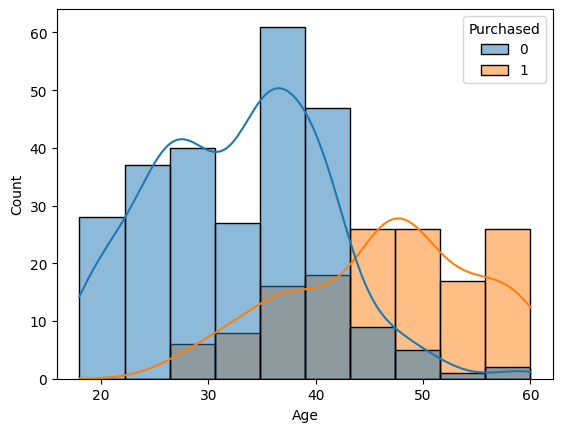

In [20]:
sns.histplot(
    data=df,
    x="Age",
    hue="Purchased",
    kde=True
)

plt.show()

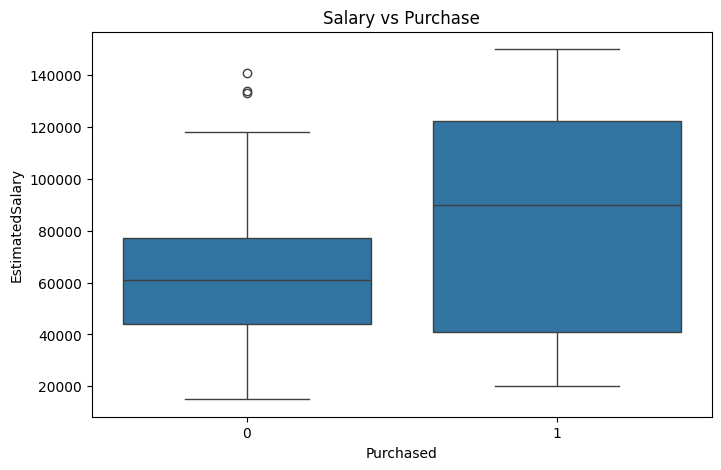

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Purchased",
    y="EstimatedSalary",
    data=df
)

plt.title("Salary vs Purchase")
plt.show()

In [22]:
df[["Age", "EstimatedSalary", "Purchased"]].corr()

,Age,EstimatedSalary,Purchased
Age,1.000000,0.155238,0.622454
EstimatedSalary,0.155238,1.000000,0.362083
Purchased,0.622454,0.362083,1.000000


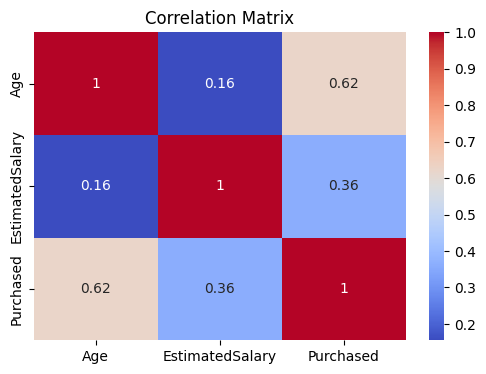

In [23]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df[["Age", "EstimatedSalary", "Purchased"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [24]:
df = df.drop("User ID", axis=1)
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [25]:
X = df.drop("Purchased", axis=1)
y = df["Purchased"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(320, 3)
(80, 3)
(320,)
(80,)


In [28]:
numerical_features = [
    "Age",
    "EstimatedSalary"
]
categorical_features = [
    "Gender"
]

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])

In [30]:
preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numerical_features
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_features
    )
])

In [31]:
from sklearn.linear_model import LogisticRegression
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000
    ))
])

In [32]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [33]:
y_pred = model.predict(X_test)
y_pred[:10]

array([1, 0, 0, 1, 0, 1, 0, 1, 1, 0])

In [34]:
y_prob = model.predict_proba(X_test)[:, 1]
y_prob[:10]

array([0.93839263, 0.00494961, 0.03662462, 0.60153966, 0.01246358,
       0.91963433, 0.37707163, 0.99200244, 0.97587102, 0.06928246])

In [35]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8125


In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[47  4]
 [11 18]]


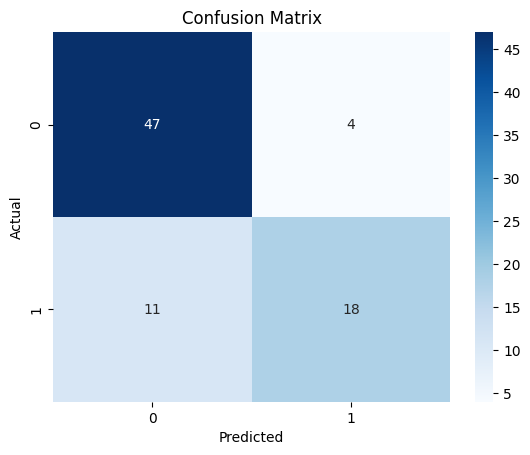

In [37]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [38]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.81      0.92      0.86        51
           1       0.82      0.62      0.71        29

    accuracy                           0.81        80
   macro avg       0.81      0.77      0.78        80
weighted avg       0.81      0.81      0.81        80



In [39]:
classifier = model.named_steps["classifier"]

print(classifier.coef_)
print(classifier.intercept_)

[[2.19611838 1.24595954 0.23368513]]
[-1.2387336]


In [40]:
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = classifier.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df

,Feature,Coefficient
0,num__Age,2.196118
1,num__EstimatedSalary,1.245960
2,cat__Gender_Male,0.233685


In [41]:
coef_df.sort_values(
    "Coefficient",
    ascending=False
)

,Feature,Coefficient
0,num__Age,2.196118
1,num__EstimatedSalary,1.245960
2,cat__Gender_Male,0.233685


In [43]:
y_pred_70 = (y_prob >= 0.70).astype(int)
accuracy_score(y_test, y_pred_70)


0.7875

In [44]:
accuracy_score(y_test, y_pred)

0.8125

In [45]:
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    
    predictions = (
        y_prob >= threshold
    ).astype(int)
    
    print(
        threshold,
        accuracy_score(y_test, predictions)
    )

0.3 0.7875
0.4 0.8125
0.5 0.8125
0.6 0.775
0.7 0.7875


Accuracy: 0.8125

Confusion Matrix:
[[47  4]
 [11 18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.92      0.86        51
           1       0.82      0.62      0.71        29

    accuracy                           0.81        80
   macro avg       0.81      0.77      0.78        80
weighted avg       0.81      0.81      0.81        80

ROC-AUC: 0.905341446923597


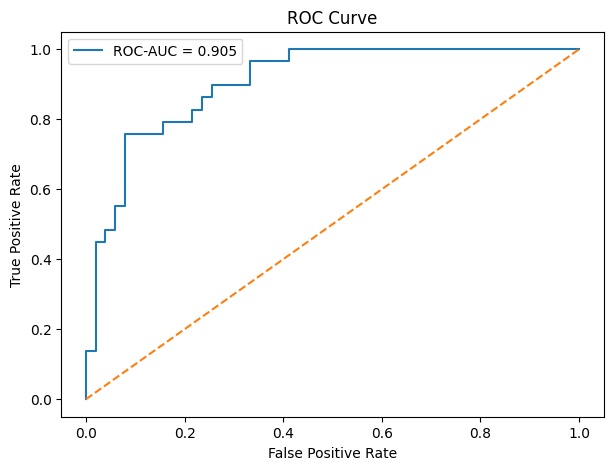

In [46]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC-AUC
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()